<a href="https://colab.research.google.com/github/EmanFatima206/student-performance-prediction/blob/main/student-performance-perdiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction

## Project Overview

This project uses machine learning to predict students' writing scores based on academic and demographic factors.

The project includes data preprocessing, model training, model comparison, performance evaluation, visualization, and cross-validation.

### Objective

The main objective is to develop and evaluate regression models that can predict students' writing scores using their available academic and demographic information.

### Models Used

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

### Evaluation Metrics

- Mean Absolute Error (MAE)
- R² Score

## 1. Import Libraries

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

## 2. Load Dataset

The Students Performance dataset is loaded directly from the project's public GitHub repository.

In [14]:
import pandas as pd

data = pd.read_csv(
    'https://raw.githubusercontent.com/EmanFatima206/student-performance-prediction/main/StudentsPerformance.csv'
)

# Show first 5 rows
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [15]:
data.shape
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Splitting Features and Defining Data Types

The dataset is separated into inputs X and the output target y.

In [16]:
# Features and target
X = data.drop('writing score', axis=1)
y = data['writing score']

# Define numerical and categorical features
numeric_features = ['math score', 'reading score']

categorical_features = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

## 4. Data Preprocessing

Categorical variables are converted into numerical features using one-hot encoding so that they can be used by the machine learning models.

In [17]:
# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

## 5. Train-Test Split and Model Training

The writing score is used as the target variable, while the remaining features are used as input features.

The dataset is divided into training and testing sets using an 80/20 split. A fixed random state is used to make the split reproducible.

In [18]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  #20% is test data
    random_state=42
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Create models
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Train models
linear_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


## 6. Model Evaluation

The trained model is evaluated using Mean Absolute Error (MAE) and R². Sample predictions are also compared with the actual writing scores.

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Make predictions
linear_pred = linear_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

# Calculate MAE
linear_mae = mean_absolute_error(y_test, linear_pred)
tree_mae = mean_absolute_error(y_test, tree_pred)
forest_mae = mean_absolute_error(y_test, forest_pred)

#calculate R2
linear_r2 = r2_score(y_test, linear_pred)
tree_r2 = r2_score(y_test, tree_pred)
forest_r2 = r2_score(y_test, forest_pred)

# Display results
print("Linear Regression - MAE:", linear_mae)
print("Linear Regression - R²:", linear_r2)

print("Decision Tree - MAE:", tree_mae)
print("Decision Tree - R²:", tree_r2)

print("Random Forest - MAE:", forest_mae)
print("Random Forest - R²:", forest_r2)

Linear Regression - MAE: 3.20027245212067
Linear Regression - R²: 0.9381328994057506
Decision Tree - MAE: 4.535
Decision Tree - R²: 0.8621466392564259
Random Forest - MAE: 3.687164761904762
Random Forest - R²: 0.9149348515999266


## 7. Actual vs Predicted Visualization

The actual and predicted writing scores are visualized to assess how closely the model's predictions match the actual values.

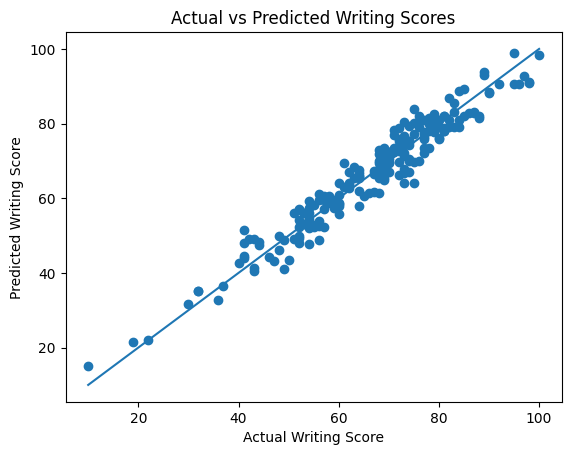

In [20]:
import matplotlib.pyplot as plt

# Actual vs predicted values
plt.scatter(y_test, linear_pred)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Labels and title
plt.xlabel("Actual Writing Score")
plt.ylabel("Predicted Writing Score")
plt.title("Actual vs Predicted Writing Scores")

plt.show()

## 8. Feature Importance and Coefficients Extraction
This step extracts the learned coefficients (weights) from the trained Linear Regression model. It maps these coefficients back to their respective numerical and one-hot encoded feature names to analyze which variables have the strongest positive or negative impact on the 'writing score'.

In [21]:
regressor = linear_model.named_steps['regressor']

coefficients = regressor.coef_

import pandas as pd

# Get feature names after one-hot encoding
onehot_features = linear_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numeric and one-hot encoded feature names
feature_names = list(numeric_features) + list(onehot_features)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance

,Feature,Coefficient
0,math score,2.916557
1,reading score,-2.916557
2,gender_female,-0.367757
3,gender_male,-0.144339
4,race/ethnicity_group A,0.491168
5,race/ethnicity_group B,1.654659
6,race/ethnicity_group C,-1.633731
7,race/ethnicity_group D,0.110304
8,race/ethnicity_group E,1.454926
9,parental level of education_associate's degree,-1.336025


In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

print("MAE for each fold:", -cv_scores)
print("Average MAE:", -cv_scores.mean())

MAE for each fold: [2.98963917 2.89227119 2.75354867 2.6248273  3.03139146]
Average MAE: 2.858335556900344


## 10. Conclusion

The evaluated models were able to predict students' writing scores with good performance.

Among the three tested models, Linear Regression achieved the best performance on the test dataset, with the lowest MAE and highest R² score.

Five-fold cross-validation was also performed to assess the consistency of model performance across different data splits.